# M1-1 — 국내 박스오피스 시계열 분석

**데이터**: 영화진흥위원회 KOBIS 오픈API 일별 박스오피스
**기간**: 2024-09-01 ~ 2026-08-31 (24개월, 730일)
**메인 시계열**: 일별 TOP10 관객수 합계 (시장 규모의 대리 지표)

## 분석 질문

- **Q1 (추세)** 2년간 국내 영화 시장은 성장했는가? 추세 전환점이 있는가?
- **Q2 (주기)** 요일에 따라 관객수가 얼마나 다른가? 수요일이 금요일보다 높은 이유는?
- **Q3 (집중도)** 관객이 몰린 날은 한 영화의 독식인가, 여러 영화의 분산인가?

> 실행 전 `python src/collect_boxoffice.py` 로 데이터를 먼저 수집해야 합니다.

## 0. 환경 설정

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

BASE = Path.cwd()
DATA = BASE / "data" / "raw_daily_boxoffice.csv"
IMG  = BASE / "images"
IMG.mkdir(exist_ok=True)

# --- 한글 폰트: 이 PC에 실제로 설치된 것만 고른다 ---
# (설치 안 된 폰트를 목록에 두면 matplotlib이 매번 findfont 경고를 쏟아낸다)
import logging
from matplotlib import font_manager
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

_installed = {f.name for f in font_manager.fontManager.ttflist}
for _cand in ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic", "Noto Sans KR"]:
    if _cand in _installed:
        plt.rcParams["font.family"] = _cand
        break
else:
    print("경고: 한글 폰트를 찾지 못했습니다. 그래프의 한글이 네모로 표시될 수 있습니다.")
plt.rcParams["axes.unicode_minus"] = False

# --- 색상 (색각 이상 대응 검증된 팔레트) ---
SURFACE   = "#fcfcfb"   # 차트 배경
INK       = "#0b0b0b"   # 주요 텍스트
INK_SUB   = "#52514e"   # 보조 텍스트
INK_MUTED = "#898781"   # 축 라벨
GRID      = "#e1e0d9"   # 격자
BASELINE  = "#c3c2b7"   # 축선
BLUE      = "#2a78d6"   # 주 계열
BLUE_PALE = "#b7d3f6"   # 배경 맥락용
ORANGE    = "#eb6834"   # 강조 계열

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SUB,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})

def tidy(ax, ygrid=True):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(ygrid, axis="y", zorder=0)
    ax.set_axisbelow(True)
    return ax

MAN = FuncFormatter(lambda v, _: f"{v:,.0f}")   # 만 명 단위 축 포맷
DOW_KR = ["월", "화", "수", "목", "금", "토", "일"]
print("설정 완료 | 사용 폰트:", plt.rcParams["font.family"][0])

설정 완료


## 1. 데이터 로드

In [2]:
df = pd.read_csv(DATA, encoding="utf-8-sig", dtype={"targetDt": str, "movieCd": str})
df["date"] = pd.to_datetime(df["targetDt"], format="%Y%m%d")
print(f"원본 {len(df):,}행 × {df.shape[1]}컬럼")
df.head(3)

원본 7,300행 × 19컬럼


,targetDt,rank,rankInten,rankOldAndNew,movieCd,movieNm,openDt,audiCnt,audiInten,audiChange,audiAcc,salesAmt,salesShare,salesInten,salesChange,salesAcc,scrnCnt,showCnt,date
0,20240901,1,0,OLD,20249188,에이리언: 로물루스,2024-08-14,76577,-23468,-23.5,1636707,763518724,20.3,-225680908,-22.8,16768102063,1009,3921,2024-09-01
1,20240901,2,0,OLD,20224666,파일럿,2024-07-31,50909,-16369,-24.3,4508839,418830521,11.1,-129252868,-23.6,41489389382,840,2752,2024-09-01
2,20240901,3,1,OLD,20249733,사랑의 하츄핑,2024-08-07,35020,-9,0.0,884846,323673290,8.6,539939,0.2,8003569812,690,1291,2024-09-01


## 2. 데이터 기본 정보 확인

기간, 컬럼, 결측치 여부를 확인한다. (요구사항 3-1)

In [3]:
print("=== 기간 ===")
print(f"  {df.date.min().date()} ~ {df.date.max().date()}")

full_range = pd.date_range(df.date.min(), df.date.max(), freq="D")
missing_dates = sorted(set(full_range) - set(df.date.unique()))
print(f"  달력상 일수 {len(full_range)}일 / 수집된 날짜 {df.date.nunique()}일")
print(f"  누락 날짜: {[d.date() for d in missing_dates] if missing_dates else '없음'}")

print("\n=== 날짜당 행 수 ===")
print(f"  {df.groupby('date').size().value_counts().to_dict()}  (API가 매일 TOP10을 반환)")

print("\n=== 결측치 (컬럼별 NaN 개수) ===")
na = df.isna().sum()
print(na[na > 0].to_dict() if na.sum() else "  NaN 없음")

print("\n=== 수치 컬럼 유효성 ===")
for c in ["audiCnt", "salesAmt", "scrnCnt", "showCnt"]:
    print(f"  {c:9} 0 이하인 행: {(df[c] <= 0).sum()}개")

print("\n=== 빈 문자열 결측 (NaN으로 안 잡히는 결측) ===")
df["openDt_missing"] = ~df["openDt"].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")
print(f"  openDt 공백: {df.openDt_missing.sum()}행")

=== 기간 ===
  2024-09-01 ~ 2026-08-31
  달력상 일수 730일 / 수집된 날짜 730일
  누락 날짜: 없음

=== 날짜당 행 수 ===
  {10: 730}  (API가 매일 TOP10을 반환)

=== 결측치 (컬럼별 NaN 개수) ===
  NaN 없음

=== 수치 컬럼 유효성 ===
  audiCnt   0 이하인 행: 0개
  salesAmt  0 이하인 행: 0개
  scrnCnt   0 이하인 행: 0개
  showCnt   0 이하인 행: 0개

=== 빈 문자열 결측 (NaN으로 안 잡히는 결측) ===
  openDt 공백: 39행


## 3. 데이터 정제 — 처리 기준과 근거

확인 결과 **일반적인 의미의 결측치·이상치는 존재하지 않는다.** 판단이 필요한 항목은 두 가지다.

### 3-1. `openDt` 공백 39행 → **유지**

공백인 행은 두 종류가 섞여 있다.
- **비정규 상영 콘텐츠**: 콘서트 실황, 아이돌 팬 이벤트, 음반 청음회 등 개봉일 개념이 없는 상영
- **정규 개봉작인데 API가 개봉일을 제공하지 않은 경우** (예: 애니메이션 `알사탕`, 22일간 차트인)

두 종류를 자동으로 구분할 규칙이 없고, 작품명을 눈으로 보고 분류하면 **재현 불가능한 수작업**이 된다.
아래 셀에서 제외 시 영향을 정량화한 뒤 판단한다.

### 3-2. 극단값 → **유지 (제거하지 않음)**

일별 관객수는 최소 5만 명 ~ 최대 152만 명으로 약 30배 차이가 난다.
통계적으로는 이상치로 분류되지만, **급등일 자체가 Q3의 분석 대상**이므로 제거하면 분석 목적이 사라진다.
"통계적 이상치이나 실제 현상이므로 유지"가 이 분석의 처리 기준이다.

In [4]:
sub = df[df.openDt_missing]
day_total = df.groupby("date").audiCnt.sum()

print("=== openDt 공백 행 제외 시 영향 ===")
print(f"  행 비중   : {len(sub)}/{len(df)} = {len(sub)/len(df)*100:.2f}%")
print(f"  관객 비중 : {sub.audiCnt.sum():,}명 / {df.audiCnt.sum():,}명 = {sub.audiCnt.sum()/df.audiCnt.sum()*100:.3f}%")
print(f"  순위 분포 : {sub['rank'].value_counts().sort_index().to_dict()}  (대부분 하위권)")

impact = (sub.groupby("date").audiCnt.sum() / day_total * 100)
print(f"\n  영향받는 날: {len(impact)}일 / 730일")
print(f"  해당일 평균 비중 {impact.mean():.2f}% / 최대 {impact.max():.2f}% ({impact.idxmax().date()})")

without = df[~df.openDt_missing].groupby("date").audiCnt.sum().reindex(day_total.index).fillna(0)
print(f"\n  일평균 관객: 포함 {day_total.mean():,.0f}명 -> 제외 {without.mean():,.0f}명 "
      f"({(without.mean()/day_total.mean()-1)*100:+.2f}%)")

print("\n결론: 영향이 0.1% 미만이고 Q1~Q3 어디에서도 openDt를 사용하지 않으므로 전량 유지한다.")
print("      (제외하면 정규 개봉작 '알사탕' 108,581명까지 함께 소실됨)")

=== openDt 공백 행 제외 시 영향 ===
  행 비중   : 39/7300 = 0.53%
  관객 비중 : 180,793명 / 214,934,675명 = 0.084%
  순위 분포 : {2: 1, 5: 3, 6: 4, 7: 4, 8: 8, 9: 6, 10: 13}  (대부분 하위권)

  영향받는 날: 730일 / 730일
  해당일 평균 비중 1.88% / 최대 12.89% (2025-03-07)

  일평균 관객: 포함 294,431명 -> 제외 294,183명 (-0.08%)

결론: 영향이 0.1% 미만이고 Q1~Q3 어디에서도 openDt를 사용하지 않으므로 전량 유지한다.
      (제외하면 정규 개봉작 '알사탕' 108,581명까지 함께 소실됨)


## 4. 일별 시계열 생성

TOP10 원본 행을 **하루 1행**으로 집계한다. 여기서 만들어지는 컬럼이 이후 분석의 전부다.

| 컬럼 | 정의 |
|---|---|
| `total_audi` | 그날 TOP10 관객수 합계 — **메인 시계열** |
| `top1_share` | 1위 영화 관객수 / `total_audi` × 100 — 시장 집중도 |
| `ma7`, `ma30` | 7일·30일 이동평균 — **기법 1** |
| `pct_change` | 전일 대비 변화율(%) — **기법 2** |
| `dow` | 요일 (0=월) — **기법 3: 요일별 집계** |

In [5]:
d = (df.groupby("date")
       .agg(total_audi=("audiCnt", "sum"),
            total_sales=("salesAmt", "sum"),
            top1_audi=("audiCnt", "max"),
            n_titles=("audiCnt", "size"))
       .sort_index())

d["top1_share"] = d.top1_audi / d.total_audi * 100
d["ma7"]        = d.total_audi.rolling(7,  center=True).mean()
d["ma30"]       = d.total_audi.rolling(30, center=True).mean()
d["pct_change"] = d.total_audi.pct_change() * 100
d["dow"]        = d.index.dayofweek
d["ym"]         = d.index.to_period("M")

# 1위 영화명 (해석용)
top1 = df.loc[df.groupby("date").audiCnt.idxmax(), ["date", "movieNm"]].set_index("date")
d["top1_movie"] = top1.movieNm

print(f"일별 시계열 {len(d)}행 생성")
print(d[["total_audi", "top1_share", "ma30", "pct_change"]].describe().round(1).to_string())

일별 시계열 730행 생성
       total_audi  top1_share      ma30  pct_change
count       730.0       730.0     701.0       729.0
mean     294431.1        48.5  289737.6        20.8
std      228390.5        16.7  102053.2        76.8
min       50078.0        17.3  137240.6       -83.5
25%      126438.0        34.7  222638.6       -18.1
50%      215099.0        45.4  265839.8        -1.9
75%      395178.0        61.1  340454.4        48.3
max     1517624.0        93.5  652258.6       557.4


---

## 5. Q1 — 2년간 시장은 성장했는가?

**기법**: 30일 이동평균. 일별 원본은 요일 효과 때문에 톱니처럼 흔들려 추세가 보이지 않는다.
30일은 요일 주기(7일)와 월 단위 변동을 모두 흡수하는 창 크기라서 선택했다.

In [6]:
y1 = d.loc["2024-09-01":"2025-08-31", "total_audi"]
y2 = d.loc["2025-09-01":"2026-08-31", "total_audi"]

print("=== 연도별 비교 (9월~8월 기준, 각 365일) ===")
print(f"  1년차 (24.09~25.08)  일평균 {y1.mean():>9,.0f}명   누적 {y1.sum():>13,.0f}명")
print(f"  2년차 (25.09~26.08)  일평균 {y2.mean():>9,.0f}명   누적 {y2.sum():>13,.0f}명")
print(f"  증감률: {(y2.sum()/y1.sum()-1)*100:+.1f}%")

print("\n=== 30일 이동평균 최고/최저 구간 ===")
ma = d.ma30.dropna()
print(f"  최고 {ma.max():,.0f}명 ({ma.idxmax().date()})")
print(f"  최저 {ma.min():,.0f}명 ({ma.idxmin().date()})")
print(f"  최고/최저 배수: {ma.max()/ma.min():.1f}배")

=== 연도별 비교 (9월~8월 기준, 각 365일) ===
  1년차 (24.09~25.08)  일평균   263,084명   누적    96,025,544명
  2년차 (25.09~26.08)  일평균   325,778명   누적   118,909,131명
  증감률: +23.8%

=== 30일 이동평균 최고/최저 구간 ===
  최고 652,259명 (2026-08-09)
  최저 137,241명 (2025-04-01)
  최고/최저 배수: 4.8배


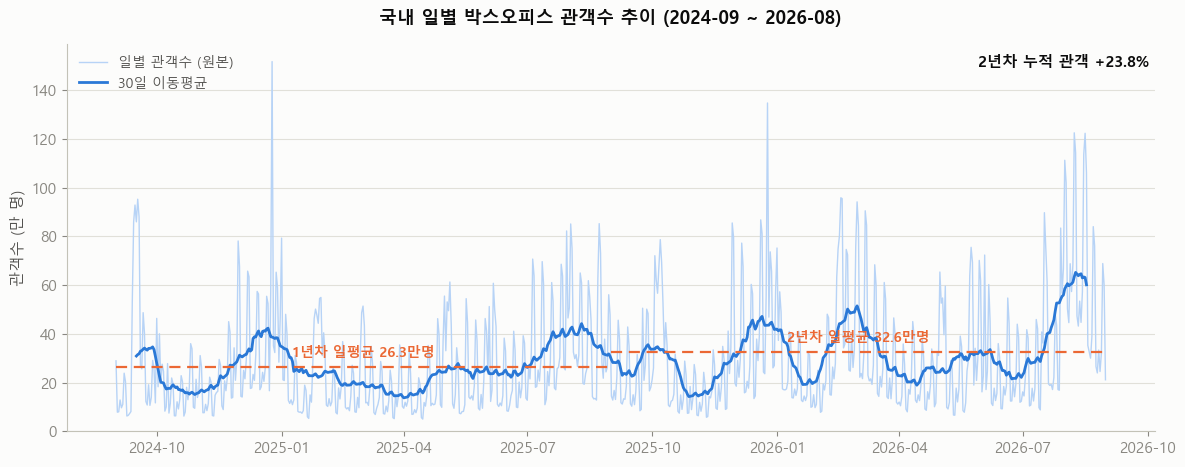

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.8))

ax.plot(d.index, d.total_audi / 1e4, color=BLUE_PALE, lw=1.0,
        label="일별 관객수 (원본)", zorder=1)
ax.plot(d.index, d.ma30 / 1e4, color=BLUE, lw=2.0,
        label="30일 이동평균", zorder=3)

# 연도별 일평균 기준선
for period, series, label in [("1년차", y1, "24.09~25.08"), ("2년차", y2, "25.09~26.08")]:
    ax.hlines(series.mean() / 1e4, series.index[0], series.index[-1],
              color=ORANGE, lw=1.6, ls=(0, (5, 3)), zorder=4)
    ax.text(series.index[len(series) // 2], series.mean() / 1e4 + 4,
            f"{period} 일평균 {series.mean()/1e4:.1f}만명",
            ha="center", color=ORANGE, fontsize=10, fontweight="bold", zorder=5)

tidy(ax)
ax.set_title("국내 일별 박스오피스 관객수 추이 (2024-09 ~ 2026-08)", color=INK, pad=14)
ax.set_ylabel("관객수 (만 명)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(MAN)
ax.set_ylim(0)
ax.legend(frameon=False, loc="upper left", fontsize=10, labelcolor=INK_SUB)
ax.text(0.995, 0.94, f"2년차 누적 관객 {(y2.sum()/y1.sum()-1)*100:+.1f}%",
        transform=ax.transAxes, ha="right", fontsize=11,
        fontweight="bold", color=INK)

fig.tight_layout()
fig.savefig(IMG / "01_trend.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 6. Q2 — 요일에 따라 관객수가 얼마나 다른가?

**기법**: 요일별 집계. 평균만 보면 공휴일이 낀 평일 때문에 값이 부풀려지므로 **중앙값을 함께** 본다.

In [8]:
dow_stat = d.groupby("dow").total_audi.agg(["mean", "median", "count"])
dow_stat.index = DOW_KR

print("=== 요일별 관객수 ===")
for k, r in dow_stat.iterrows():
    print(f"  {k}: 평균 {r['mean']:>9,.0f}   중앙값 {r['median']:>9,.0f}   (n={int(r['count'])})")

print(f"\n  평균 기준 최대/최소 배수: {dow_stat['mean'].max()/dow_stat['mean'].min():.2f}배 "
      f"({dow_stat['mean'].idxmax()} / {dow_stat['mean'].idxmin()})")

print("\n=== 주의: 평균과 중앙값의 순위가 다르다 ===")
print(f"  평균   기준 순위: {' > '.join(dow_stat['mean'].sort_values(ascending=False).index)}")
print(f"  중앙값 기준 순위: {' > '.join(dow_stat['median'].sort_values(ascending=False).index)}")
print(f"\n  수요일 vs 금요일")
print(f"    평균   : 수 {dow_stat.loc['수','mean']:,.0f}  >  금 {dow_stat.loc['금','mean']:,.0f}   "
      f"({dow_stat.loc['수','mean']-dow_stat.loc['금','mean']:+,.0f}명)")
print(f"    중앙값 : 수 {dow_stat.loc['수','median']:,.0f}  <  금 {dow_stat.loc['금','median']:,.0f}   "
      f"({dow_stat.loc['수','median']-dow_stat.loc['금','median']:+,.0f}명)")
print("\n  -> '수요일 역전'은 평균에서만 나타난다. 소수의 극단값이 평균을 끌어올렸다는 신호다.")

=== 요일별 관객수 ===
  월: 평균   188,969   중앙값   119,139   (n=105)
  화: 평균   179,588   중앙값   116,203   (n=104)
  수: 평균   268,319   중앙값   183,772   (n=104)
  목: 평균   205,006   중앙값   146,604   (n=104)
  금: 평균   262,464   중앙값   211,252   (n=104)
  토: 평균   502,627   중앙값   460,588   (n=104)
  일: 평균   453,528   중앙값   398,067   (n=105)

  평균 기준 최대/최소 배수: 2.80배 (토 / 화)

=== 주의: 평균과 중앙값의 순위가 다르다 ===
  평균   기준 순위: 토 > 일 > 수 > 금 > 목 > 월 > 화
  중앙값 기준 순위: 토 > 일 > 금 > 수 > 목 > 월 > 화

  수요일 vs 금요일
    평균   : 수 268,319  >  금 262,464   (+5,854명)
    중앙값 : 수 183,772  <  금 211,252   (-27,480명)

  -> '수요일 역전'은 평균에서만 나타난다. 소수의 극단값이 평균을 끌어올렸다는 신호다.


### 6-1. 수요일 역전 현상 — 관찰을 한 겹 더 벗겨보기

**1차 관찰**: 수요일 평균(268,319명)이 금요일 평균(262,464명)보다 높다.
주말 직전인 금요일이 더 높을 것이라는 직관과 어긋난다.

**2차 관찰 (반전)**: 그런데 **중앙값**으로 보면 금요일(211,252명)이 수요일(183,772명)보다 **높다.**
즉 '수요일 역전'은 평균에서만 나타나는 현상이다.
평균과 중앙값의 순위가 엇갈린다는 것은 **소수의 극단값이 수요일 평균을 끌어올렸다**는 뜻이다.

**가설**: 매월 마지막 수요일 '문화가 있는 날'(영화관 할인)에 해당하는 소수의 날이
수요일 평균을 선택적으로 끌어올렸다.

아래에서 마지막 수요일과 나머지 수요일을 분리해 검증하고, **가설의 한계도 함께 확인**한다.

In [9]:
wed = d[d.dow == 2].copy()
last_wed = wed.reset_index().groupby("ym")["date"].max()
wed["is_last"] = wed.index.isin(last_wed)

lw, ow = wed[wed.is_last].total_audi, wed[~wed.is_last].total_audi
fri = d[d.dow == 4].total_audi

print("=== 가설 검증 ===")
print(f"  마지막 수요일 (n={len(lw):>3})  평균 {lw.mean():>9,.0f}명")
print(f"  그 외 수요일  (n={len(ow):>3})  평균 {ow.mean():>9,.0f}명")
print(f"  금요일        (n={len(fri):>3})  평균 {fri.mean():>9,.0f}명")
print(f"\n  배수: 마지막 수요일 / 그 외 수요일 = {lw.mean()/ow.mean():.2f}배")

print("\n=== 반증 점검: 마지막 수요일 상위 6일에 무엇이 섞여 있나 ===")
for dt, v in lw.nlargest(6).items():
    print(f"  {dt.date()}  {v:>9,.0f}명   1위: {d.loc[dt,'top1_movie']}")
print("\n  -> 크리스마스/연말/여름 성수기가 섞여 있다.")
print("     1.72배 전부를 할인 효과로 볼 수 없으며, 계절 효과가 분리되지 않았다.")

=== 가설 검증 ===
  마지막 수요일 (n= 24)  평균   396,318명
  그 외 수요일  (n= 80)  평균   229,919명
  금요일        (n=104)  평균   262,464명

  배수: 마지막 수요일 / 그 외 수요일 = 1.72배

=== 반증 점검: 마지막 수요일 상위 6일에 무엇이 섞여 있나 ===
  2024-12-25  1,517,624명   1위: 하얼빈
  2026-07-29    834,233명   1위: 스파이더맨: 브랜드 뉴 데이
  2025-07-30    822,289명   1위: 좀비딸
  2025-12-31    581,849명   1위: 아바타: 불과 재
  2025-01-29    545,295명   1위: 히트맨2
  2025-09-24    505,260명   1위: 어쩔수가없다

  -> 크리스마스/연말/여름 성수기가 섞여 있다.
     1.72배 전부를 할인 효과로 볼 수 없으며, 계절 효과가 분리되지 않았다.


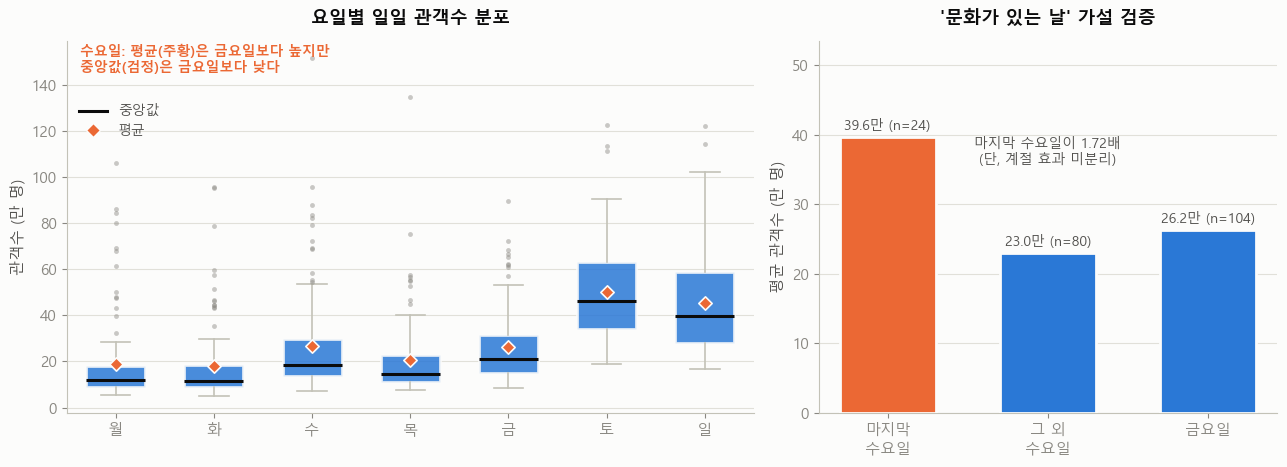

In [10]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8),
                         gridspec_kw={"width_ratios": [1.5, 1]})

# --- 좌: 요일별 분포 (중앙값=검은 선, 평균=주황 마름모) ---
ax = axes[0]
data_by_dow = [d[d.dow == i].total_audi.values / 1e4 for i in range(7)]
bp = ax.boxplot(data_by_dow, patch_artist=True, widths=0.6, zorder=3,
                medianprops=dict(color=INK, lw=2.2),
                whiskerprops=dict(color=BASELINE, lw=1.2),
                capprops=dict(color=BASELINE, lw=1.2),
                flierprops=dict(marker="o", ms=3.5, mfc=INK_MUTED,
                                mec="none", alpha=0.45))
for box in bp["boxes"]:
    box.set(facecolor=BLUE, alpha=0.85, edgecolor=SURFACE, linewidth=2)

means = [d[d.dow == i].total_audi.mean() / 1e4 for i in range(7)]
ax.scatter(range(1, 8), means, marker="D", s=46, color=ORANGE,
           edgecolor=SURFACE, linewidth=1.2, zorder=5)

tidy(ax)
ax.set_xticklabels(DOW_KR)
ax.set_title("요일별 일일 관객수 분포", color=INK, pad=12)
ax.set_ylabel("관객수 (만 명)")
ax.yaxis.set_major_formatter(MAN)
ax.legend(handles=[Line2D([], [], color=INK, lw=2.2, label="중앙값"),
                   Line2D([], [], marker="D", ls="none", ms=7, color=ORANGE,
                          mec=SURFACE, label="평균")],
          frameon=False, loc="upper left", fontsize=10, labelcolor=INK_SUB,
          bbox_to_anchor=(0.0, 0.86))
ax.text(0.02, 0.99,
        "수요일: 평균(주황)은 금요일보다 높지만\n중앙값(검정)은 금요일보다 낮다",
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
        color=ORANGE, fontweight="bold")

# --- 우: 수요일 분해 ---
ax = axes[1]
labels = ["마지막\n수요일", "그 외\n수요일", "금요일"]
vals   = [lw.mean() / 1e4, ow.mean() / 1e4, fri.mean() / 1e4]
bars = ax.bar(labels, vals, color=[ORANGE, BLUE, BLUE], width=0.6,
              edgecolor=SURFACE, linewidth=2, zorder=3)
for b, v, n in zip(bars, vals, [len(lw), len(ow), len(fri)]):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.0, f"{v:.1f}만 (n={n})",
            ha="center", fontsize=10, color=INK_SUB)

tidy(ax)
ax.set_title("'문화가 있는 날' 가설 검증", color=INK, pad=12)
ax.set_ylabel("평균 관객수 (만 명)")
ax.yaxis.set_major_formatter(MAN)
ax.set_ylim(0, max(vals) * 1.35)
ax.text(0.50, 0.74, f"마지막 수요일이 {lw.mean()/ow.mean():.2f}배\n(단, 계절 효과 미분리)",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=10, color=INK_SUB)

fig.tight_layout()
fig.savefig(IMG / "02_weekday.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 7. Q3 — 관객이 몰린 날은 독식인가 분산인가?

**기법**: 전일 대비 변화율 + 1위 점유율. 시장 규모(`total_audi`)와 집중도(`top1_share`)의 관계를 본다.

In [11]:
hi = d[d.total_audi >= d.total_audi.quantile(0.9)]
lo = d[d.total_audi <= d.total_audi.quantile(0.1)]

print("=== 규모와 집중도의 관계 ===")
print(f"  피어슨 상관계수: {d.total_audi.corr(d.top1_share):.3f}")
print(f"  상위 10% 관객일 (n={len(hi)})  평균 1위 점유율 {hi.top1_share.mean():.1f}%")
print(f"  하위 10% 관객일 (n={len(lo)})  평균 1위 점유율 {lo.top1_share.mean():.1f}%")
print(f"  전체 평균 점유율 {d.top1_share.mean():.1f}% (최소 {d.top1_share.min():.1f}% / 최대 {d.top1_share.max():.1f}%)")

print("\n=== 전일 대비 급등 상위 5일 ===")
for dt, r in d.nlargest(5, "pct_change").iterrows():
    print(f"  {dt.date()} ({DOW_KR[r.dow]}) {r['pct_change']:+6.1f}%  "
          f"{r.total_audi:>9,.0f}명  1위 {r.top1_share:4.1f}%  {r.top1_movie}")

print("\n=== 점유율 최고 5일 (독식 사례) ===")
for dt, r in d.nlargest(5, "top1_share").iterrows():
    print(f"  {dt.date()}  점유율 {r.top1_share:4.1f}%  {r.total_audi:>9,.0f}명  {r.top1_movie}")

=== 규모와 집중도의 관계 ===
  피어슨 상관계수: 0.341
  상위 10% 관객일 (n=73)  평균 1위 점유율 62.6%
  하위 10% 관객일 (n=73)  평균 1위 점유율 36.9%
  전체 평균 점유율 48.5% (최소 17.3% / 최대 93.5%)

=== 전일 대비 급등 상위 5일 ===
  2024-09-13 (금) +557.4%    532,190명  1위 93.5%  베테랑2
  2025-09-24 (수) +462.3%    505,260명  1위 65.6%  어쩔수가없다
  2025-05-17 (토) +399.2%    544,471명  1위 77.9%  미션 임파서블: 파이널 레코닝
  2026-07-29 (수) +394.7%    834,233명  1위 82.8%  스파이더맨: 브랜드 뉴 데이
  2025-08-22 (금) +385.7%    622,844명  1위 83.2%  극장판 귀멸의 칼날: 무한성편

=== 점유율 최고 5일 (독식 사례) ===
  2024-09-13  점유율 93.5%    532,190명  베테랑2
  2024-09-17  점유율 89.7%    952,643명  베테랑2
  2024-09-16  점유율 88.9%    859,762명  베테랑2
  2024-09-15  점유율 88.8%    928,757명  베테랑2
  2026-03-09  점유율 88.3%    230,046명  왕과 사는 남자


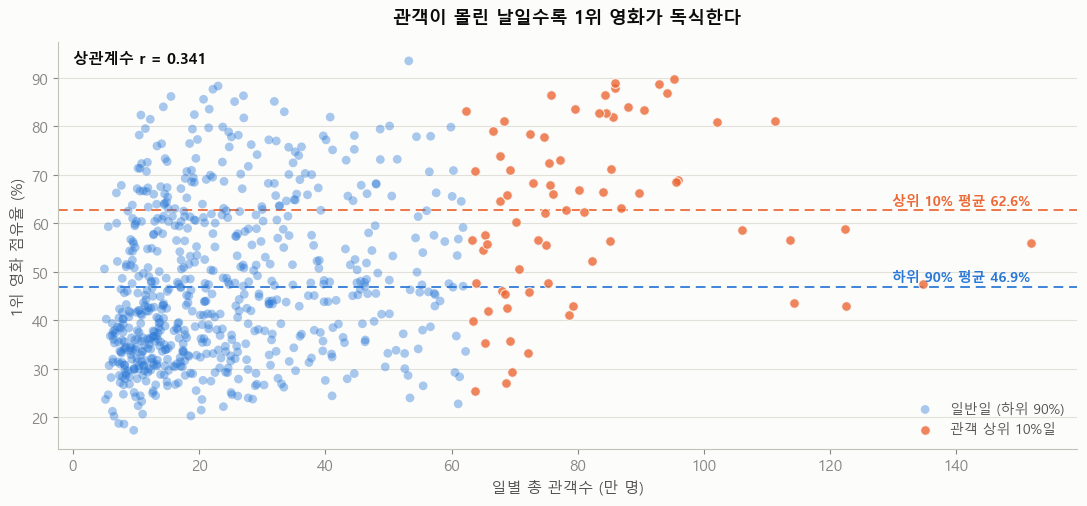

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.2))

is_hi = d.total_audi >= d.total_audi.quantile(0.9)
ax.scatter(d.loc[~is_hi, "total_audi"] / 1e4, d.loc[~is_hi, "top1_share"],
           s=40, color=BLUE, alpha=0.40, edgecolor="none",
           label="일반일 (하위 90%)", zorder=2)
ax.scatter(d.loc[is_hi, "total_audi"] / 1e4, d.loc[is_hi, "top1_share"],
           s=48, color=ORANGE, alpha=0.80, edgecolor=SURFACE, linewidth=0.8,
           label="관객 상위 10%일", zorder=3)

# 두 집단의 평균 점유율 기준선
for series, color, txt in [(d[~is_hi], BLUE, "하위 90%"), (d[is_hi], ORANGE, "상위 10%")]:
    ax.axhline(series.top1_share.mean(), color=color, lw=1.4, ls=(0, (5, 3)),
               alpha=0.9, zorder=1)
    ax.text(d.total_audi.max() / 1e4, series.top1_share.mean() + 1.2,
            f"{txt} 평균 {series.top1_share.mean():.1f}%",
            ha="right", fontsize=10, color=color, fontweight="bold")

tidy(ax)
ax.set_title("관객이 몰린 날일수록 1위 영화가 독식한다", color=INK, pad=14)
ax.set_xlabel("일별 총 관객수 (만 명)")
ax.set_ylabel("1위 영화 점유율 (%)")
ax.xaxis.set_major_formatter(MAN)
ax.legend(frameon=False, loc="lower right", fontsize=10, labelcolor=INK_SUB)
ax.text(0.015, 0.95, f"상관계수 r = {d.total_audi.corr(d.top1_share):.3f}",
        transform=ax.transAxes, fontsize=11, fontweight="bold", color=INK)

fig.tight_layout()
fig.savefig(IMG / "03_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 8. 리포트용 근거 수치 요약

아래 출력값을 `REPORT.md` 5장 인사이트의 **관찰(Fact)** 칸에 그대로 옮긴다.

In [13]:
print("=" * 62)
print("Q1 추세")
print(f"  2년차 누적 관객 증감           : {(y2.sum()/y1.sum()-1)*100:+.1f}%")
print(f"  1년차 / 2년차 일평균           : {y1.mean():,.0f}명 / {y2.mean():,.0f}명")
print(f"  30일 이동평균 최고/최저 배수   : {d.ma30.max()/d.ma30.min():.1f}배")
print("=" * 62)
print("Q2 요일")
print(f"  토요일 / 화요일 평균 배수      : {dow_stat.loc['토','mean']/dow_stat.loc['화','mean']:.2f}배")
print(f"  수요일 - 금요일 (평균)         : {dow_stat.loc['수','mean']-dow_stat.loc['금','mean']:+,.0f}명  <- 수요일이 높음")
print(f"  수요일 - 금요일 (중앙값)       : {dow_stat.loc['수','median']-dow_stat.loc['금','median']:+,.0f}명  <- 금요일이 높음")
print(f"  마지막 수요일 / 그 외 수요일   : {lw.mean()/ow.mean():.2f}배")
print(f"  월요일 평균 vs 중앙값          : {dow_stat.loc['월','mean']:,.0f} vs {dow_stat.loc['월','median']:,.0f} (공휴일 꼬리)")
print("=" * 62)
print("Q3 집중도")
print(f"  총관객 x 1위점유율 상관계수    : {d.total_audi.corr(d.top1_share):.3f}")
print(f"  상위10%일 / 하위10%일 점유율   : {hi.top1_share.mean():.1f}% / {lo.top1_share.mean():.1f}%")
print(f"  점유율 최대                    : {d.top1_share.max():.1f}% ({d.top1_share.idxmax().date()}, {d.loc[d.top1_share.idxmax(),'top1_movie']})")
print("=" * 62)
print("데이터 정제")
print(f"  누락 날짜                      : {len(missing_dates)}건")
print(f"  openDt 공백 행                 : {df.openDt_missing.sum()}행 (관객 비중 {sub.audiCnt.sum()/df.audiCnt.sum()*100:.3f}%) -> 유지")
print(f"  극단값                         : 최소 {d.total_audi.min():,.0f} ~ 최대 {d.total_audi.max():,.0f}명 ({d.total_audi.max()/d.total_audi.min():.0f}배) -> 유지")
print("=" * 62)

Q1 추세
  2년차 누적 관객 증감           : +23.8%
  1년차 / 2년차 일평균           : 263,084명 / 325,778명
  30일 이동평균 최고/최저 배수   : 4.8배
Q2 요일
  토요일 / 화요일 평균 배수      : 2.80배
  수요일 - 금요일 (평균)         : +5,854명  <- 수요일이 높음
  수요일 - 금요일 (중앙값)       : -27,480명  <- 금요일이 높음
  마지막 수요일 / 그 외 수요일   : 1.72배
  월요일 평균 vs 중앙값          : 188,969 vs 119,139 (공휴일 꼬리)
Q3 집중도
  총관객 x 1위점유율 상관계수    : 0.341
  상위10%일 / 하위10%일 점유율   : 62.6% / 36.9%
  점유율 최대                    : 93.5% (2024-09-13, 베테랑2)
데이터 정제
  누락 날짜                      : 0건
  openDt 공백 행                 : 39행 (관객 비중 0.084%) -> 유지
  극단값                         : 최소 50,078 ~ 최대 1,517,624명 (30배) -> 유지
